# Part 1 - Data Collection

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

首次运行请先运行data_collection.ipynb

In [2]:
# 第一次运行完上面代码后，后面再运行就直接run这个cell
stocks = pd.read_csv('../data/raw_stocks.csv', index_col=0)
tickers = stocks['Ticker'].unique().tolist()
stocks.head()

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume
0,2015-01-02,a,37.054733,40.560001,41.310001,40.369999,41.180000,1529200.0
1,2015-01-02,aapl,24.214886,27.332500,27.860001,26.837500,27.847500,212818400.0
2,2015-01-02,abbv,41.755470,65.889999,66.400002,65.440002,65.440002,5086100.0
4,2015-01-02,abt,36.235119,44.900002,45.450001,44.639999,45.250000,3216600.0
5,2015-01-02,acgl,18.539352,19.496668,19.860001,19.426666,19.733334,1101600.0


确定数据范围：<br>从S&P 500中选取若干作为投资组合，此处选择科技股年均日成交额Top50作限定。

In [3]:
# 股票池筛选：科技行业 + 流动性 Top 50

# 获取每只股票的行业信息
# 从已有的 tickers 列表中批量查询 sector
print("正在获取行业信息（需要10+分钟）...")

sector_map = {}
for ticker in tickers:
    try:
        # 这里查询的是今天的行业分类，不是2015年的。有一点遗留问题。
        info = yf.Ticker(ticker).info
        sector_map[ticker.lower()] = info.get('sector', 'Unknown')
    except:
        sector_map[ticker.lower()] = 'Unknown'

# 筛出科技行业的股票代码
tech_tickers = [t for t, s in sector_map.items() if s == 'Technology']
print(f"科技行业股票数量: {len(tech_tickers)}")

# 先把 stocks 裁剪到科技行业
stocks = stocks[stocks['Ticker'].isin(tech_tickers)].copy()
print(f"筛选科技行业后数据量: {stocks.shape}")

# 计算每只股票的年均日成交额（流动性指标）
# 用收盘价 × 成交量，取全部时间的均值
# 注意避免look-ahead bias，只用前两年数据决定股票池！
selection_cutoff = '2016-12-31'
stocks['dollar_volume'] = stocks['Close'] * stocks['Volume']
liquidity = (
    stocks[stocks['Date'] <= selection_cutoff]
    .groupby('Ticker')['dollar_volume']
    .mean()
    .sort_values(ascending=False)
)

# 取流动性 Top 50
top50_tickers = liquidity.head(50).index.tolist()
stocks = stocks[stocks['Ticker'].isin(top50_tickers)].copy()
stocks = stocks.drop(columns=['dollar_volume'])  # 清理临时列

print(f"\n最终股票池: {len(top50_tickers)} 只股票")
print(f"最终数据量: {stocks.shape}")
print(f"股票列表: {sorted(top50_tickers)}")

正在获取行业信息（需要10+分钟）...
科技行业股票数量: 81
筛选科技行业后数据量: (204939, 8)

最终股票池: 50 只股票
最终数据量: (130863, 8)
股票列表: ['aapl', 'acn', 'adbe', 'adi', 'adp', 'adsk', 'akam', 'amat', 'amd', 'aph', 'avgo', 'cpay', 'crm', 'csco', 'ctsh', 'dell', 'ffiv', 'fis', 'fslr', 'ftnt', 'ftv', 'gen', 'glw', 'hpe', 'hpq', 'ibm', 'intc', 'intu', 'klac', 'lrcx', 'mchp', 'msft', 'msi', 'mu', 'now', 'ntap', 'nvda', 'nxpi', 'orcl', 'panw', 'payx', 'qcom', 'rop', 'stx', 'swks', 'tel', 'txn', 'vrsn', 'wday', 'wdc']


In [4]:
# 第一次运行notebook时保存，以防万一。之后请注释掉。
# 这里为了固化股票池，每次获取行业信息都是实时的，可能导致偏差。
import json
with open('../data/top50_tickers_final.json', 'w') as f:
    json.dump(sorted(top50_tickers), f, indent=2)
stocks.to_csv('../data/raw_stocks_tech.csv')
print("股票池已固化保存")

股票池已固化保存


In [5]:
# 第二次及以后运行
stocks = pd.read_csv('../data/raw_stocks_tech.csv', index_col=0)
top50_tickers = stocks['Ticker'].unique().tolist()
stocks.head()

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume
1,2015-01-02,aapl,24.214886,27.332500,27.860001,26.837500,27.847500,212818400.0
6,2015-01-02,acn,74.252617,88.839996,90.089996,88.430000,89.669998,2021300.0
7,2015-01-02,adbe,72.339996,72.339996,73.199997,71.889999,72.699997,2349200.0
8,2015-01-02,adi,44.216045,55.540001,56.250000,54.970001,55.680000,1323200.0
10,2015-01-02,adp,65.562561,83.290001,84.180000,82.519997,82.980003,1866600.0


计算真实收益率

In [6]:
stocks['Return'] = stocks.groupby('Ticker')['Adj Close'].pct_change()
stocks = stocks.reset_index(drop = True)
stocks.head()

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Return
0,2015-01-02,aapl,24.214886,27.332500,27.860001,26.837500,27.847500,212818400.0,NaN
1,2015-01-02,acn,74.252617,88.839996,90.089996,88.430000,89.669998,2021300.0,NaN
2,2015-01-02,adbe,72.339996,72.339996,73.199997,71.889999,72.699997,2349200.0,NaN
3,2015-01-02,adi,44.216045,55.540001,56.250000,54.970001,55.680000,1323200.0,NaN
4,2015-01-02,adp,65.562561,83.290001,84.180000,82.519997,82.980003,1866600.0,NaN


# Part 2 - Alpha Generation & Evaluatioon

In [7]:
from numpy import abs
from numpy import log
from numpy import sign
from scipy.stats import rankdata

In [8]:
stocks['VWAP'] = stocks[['High', 'Low', 'Close']].mean(axis = 1)
stocks['adv20'] = stocks.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(20).mean())
stocks.head()

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Return,VWAP,adv20
0,2015-01-02,aapl,24.214886,27.332500,27.860001,26.837500,27.847500,212818400.0,NaN,27.343334,NaN
1,2015-01-02,acn,74.252617,88.839996,90.089996,88.430000,89.669998,2021300.0,NaN,89.119998,NaN
2,2015-01-02,adbe,72.339996,72.339996,73.199997,71.889999,72.699997,2349200.0,NaN,72.476664,NaN
3,2015-01-02,adi,44.216045,55.540001,56.250000,54.970001,55.680000,1323200.0,NaN,55.586667,NaN
4,2015-01-02,adp,65.562561,83.290001,84.180000,82.519997,82.980003,1866600.0,NaN,83.329999,NaN


### 生成alpha因子

In [9]:
# 编写py函数作为此处计算因子方法，简化界面。
import sys
sys.path.append('../src')

from alphas import compute_all_alphas
stocks, alpha_cols = compute_all_alphas(stocks)

开始计算101 Alphas + 自定义因子...

计算完成! 成功: 85个, 跳过(缺IndClass/cap): 23个


In [13]:
# 第一次运行notebook时保存，以防万一。之后请注释掉。
# stocks.to_csv('../data/stocks_tech_with_alphas.csv')

In [12]:
# 第二次及以后运行
# shape应为 5×96，若有问题请重新运行
stocks = pd.read_csv('../data/stocks_tech_with_alphas.csv', index_col = 0)
stocks.head()

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Return,VWAP,...,alpha_099,alpha_100,alpha_101,alpha_cust_rev1,alpha_cust_rev10,alpha_cust_mom60,alpha_cust_mom120,alpha_cust_vratio,alpha_cust_vtrend,alpha_cust_volchg
0,2015-01-02,aapl,24.214886,27.332500,27.860001,26.837500,27.847500,212818400.0,NaN,27.343334,...,0,NaN,-0.503174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-02,acn,74.252617,88.839996,90.089996,88.430000,89.669998,2021300.0,NaN,89.119998,...,0,NaN,-0.499701,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-02,adbe,72.339996,72.339996,73.199997,71.889999,72.699997,2349200.0,NaN,72.476664,...,0,NaN,-0.274601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-02,adi,44.216045,55.540001,56.250000,54.970001,55.680000,1323200.0,NaN,55.586667,...,0,NaN,-0.109289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-02,adp,65.562561,83.290001,84.180000,82.519997,82.980003,1866600.0,NaN,83.329999,...,0,NaN,0.186633,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 异常值检测 + 标准化

此处异常值检测采用的MAD方法，标准化TS和CS均有涉猎。

等待时间：15min+

In [15]:
def winsorize_mad(series, n_mad=3):
    """要求 1: Median Absolute Deviation (MAD), 中位数 +/- 3个MAD"""
    median = series.median()
    mad = (series - median).abs().median() * 1.4826
    lower = median - n_mad * mad
    upper = median + n_mad * mad
    return series.clip(lower, upper)

# 
for col in alpha_cols:
    # cross-sectional去极值
    stocks[col] = stocks.groupby('Date')[col].transform(winsorize_mad)
    
    # TS z-score（每只股票用自己过去60天的均值和标准差标准化）
    stocks[col] = stocks.groupby('Ticker')[col].transform(
        lambda x: (x - x.rolling(60).mean()) / x.rolling(60).std()
    )

    # 再做一次cross-sectional去极值（TS之后可能产生新的极端值）
    stocks[col] = stocks.groupby('Date')[col].transform(winsorize_mad)
    
    # CS z-score（每天对所有股票标准化）
    stocks[col] = stocks.groupby('Date')[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

stocks[stocks['Ticker'] == 'aapl'].head(10)

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Return,VWAP,...,alpha_099,alpha_100,alpha_101,alpha_cust_rev1,alpha_cust_rev10,alpha_cust_mom60,alpha_cust_mom120,alpha_cust_vratio,alpha_cust_vtrend,alpha_cust_volchg
0,2015-01-02,aapl,24.214886,27.332500,27.860001,26.837500,27.847500,212818400.0,NaN,27.343334,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,2015-01-05,aapl,23.532717,26.562500,27.162500,26.352501,27.072500,257142000.0,-0.028171,26.692500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,2015-01-06,aapl,23.534937,26.565001,26.857500,26.157499,26.635000,263188400.0,0.000094,26.526667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
141,2015-01-07,aapl,23.864948,26.937500,27.049999,26.674999,26.799999,160423600.0,0.014022,26.887499,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188,2015-01-08,aapl,24.781891,27.972500,28.037500,27.174999,27.307501,237458000.0,0.038422,27.728333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
235,2015-01-09,aapl,24.808470,28.002501,28.312500,27.552500,28.167500,214798000.0,0.001073,27.955833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
282,2015-01-12,aapl,24.197178,27.312500,28.157499,27.200001,28.150000,198603200.0,-0.024640,27.556667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
329,2015-01-13,aapl,24.412020,27.555000,28.200001,27.227501,27.857500,268367600.0,0.008879,27.660834,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
376,2015-01-14,aapl,24.318985,27.450001,27.622499,27.125000,27.260000,195826400.0,-0.003811,27.399167,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
423,2015-01-15,aapl,23.658962,26.705000,27.514999,26.665001,27.500000,240056000.0,-0.027140,26.961667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# 第一次运行notebook时保存，以防万一。之后请注释掉。
# stocks.to_csv('../data/stocks_tech_with_alphas_z.csv')

In [18]:
# 第二次及以后运行
# 若前面无问题，也可从此处开始向下运行。
stocks = pd.read_csv('../data/stocks_tech_with_alphas_z.csv', index_col = 0)
alpha_cols = [c for c in stocks.columns if c.startswith('alpha_') and c != 'alpha_combined']
print(f"恢复因子: {len(alpha_cols)}个")

恢复因子: 85个


### 探索性数据分析
目标：评估alpha因子有效性，去除噪声/极端因子。

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

1. 分布可视化：此处因子数过多，暂不做visualization。之前在简易版中做过相关内容，可参考 `project_1_simple.ipynb`。

2. 统计量计算：见下。

In [20]:
from scipy.stats import skew, kurtosis

eda_stats = pd.DataFrame({
    'Mean': stocks[alpha_cols].mean(),
    'Std': stocks[alpha_cols].std(),
    'Skewness': stocks[alpha_cols].apply(lambda x: skew(x, nan_policy='omit')),
    'Kurtosis': stocks[alpha_cols].apply(lambda x: kurtosis(x, nan_policy='omit')),
    'Min': stocks[alpha_cols].min(),
    'Max': stocks[alpha_cols].max(),
})
print(eda_stats.round(4))

                   Mean     Std  Skewness  Kurtosis     Min     Max
alpha_001          -0.0  0.9898    0.0364   -0.8556 -3.1985  3.3830
alpha_002          -0.0  0.9899    0.0571   -0.4944 -3.2874  3.2732
alpha_003           0.0  0.9248    0.0235   -0.8096 -2.6679  2.4857
alpha_004           0.0  0.9895    0.0035   -0.1934 -3.5332  3.2902
alpha_005          -0.0  0.9899   -0.6486   -0.5908 -3.4778  2.6134
...                 ...     ...       ...       ...     ...     ...
alpha_cust_mom60    0.0  0.9899    0.0926   -0.3805 -3.3417  3.3266
alpha_cust_mom120   0.0  0.9899    0.0538   -0.4412 -3.1733  3.4454
alpha_cust_vratio   0.0  0.9899    0.4962   -0.1304 -2.9369  3.5216
alpha_cust_vtrend   0.0  0.9899   -0.1150   -0.5054 -3.4598  3.1496
alpha_cust_volchg   0.0  0.9899   -0.0508   -0.3797 -3.4829  3.3380

[85 rows x 6 columns]


3. 经济逻辑验证：计算IC评估。<br>
   计算每日因子值与未来5期收益率的 Spearman 秩相关系数，评估单因子的预测能力与有效性。<br>
   （测算当天的因子大小与股票未来 5 天涨跌幅的相关性（即 IC 值）。相关性越高，说明该因子的选股预测能力越强）

In [21]:
# 贴标签，5天后的Return
stocks['Return_next'] = stocks.groupby('Ticker')['Adj Close'].pct_change(5).shift(-5)

等待时间：20min+

In [22]:
# 每天计算每个alpha和明天收益的相关系数
ic_results = {}

for col in alpha_cols:
    daily_ic = stocks.groupby('Date').apply(
        lambda x: spearmanr(
            x[[col, 'Return_next']].dropna()[col],
            x[[col, 'Return_next']].dropna()['Return_next']
        )[0]
    )
    ic_results[col] = {
        'IC Mean': daily_ic.mean(),
        'IC Std': daily_ic.std(),
        'ICIR': daily_ic.mean() / daily_ic.std(),
        'IC > 0 (%)': (daily_ic > 0).mean() * 100
    }

ic_df = pd.DataFrame(ic_results).T.round(4)
print(ic_df)

                   IC Mean  IC Std    ICIR  IC > 0 (%)
alpha_001           0.0053  0.1472  0.0359     49.3364
alpha_002          -0.0004  0.1419 -0.0029     47.8195
alpha_003          -0.0006  0.5004 -0.0012     46.8335
alpha_004           0.0097  0.1399  0.0692     52.2943
alpha_005           0.0181  0.1390  0.1305     53.6215
...                    ...     ...     ...         ...
alpha_cust_mom60    0.0048  0.1400  0.0342     49.9431
alpha_cust_mom120  -0.0037  0.1420 -0.0262     45.9234
alpha_cust_vratio  -0.0085  0.1469 -0.0576     46.7577
alpha_cust_vtrend  -0.0064  0.1411 -0.0450     45.9613
alpha_cust_volchg  -0.0069  0.1402 -0.0494     46.0751

[85 rows x 4 columns]


In [24]:
# 第一次运行notebook时保存，以防万一。之后请注释掉。
# ic_df.to_csv('../data/alphas_ic.csv')

In [25]:
# 第二次及以后运行
ic_df = pd.read_csv('../data/alphas_ic.csv', index_col = 0)
ic_df.head()

,IC Mean,IC Std,ICIR,IC > 0 (%)
alpha_001,0.0053,0.1472,0.0359,49.3364
alpha_002,-0.0004,0.1419,-0.0029,47.8195
alpha_003,-0.0006,0.5004,-0.0012,46.8335
alpha_004,0.0097,0.1399,0.0692,52.2943
alpha_005,0.0181,0.1390,0.1305,53.6215


根据首轮IC评估信息调整因子。

In [26]:
# 观察 alphas_ic.csv，有NaN值，先将其剔除。
ic_df = ic_df.dropna(axis=0, how='any')
# IC Mean绝对值<0.001的因子，预测能力极弱，剔除
ic_df = ic_df[np.abs(ic_df['IC Mean']) > 0.001]

# 去掉stacks中的对应因子列
valid_alphas = ic_df.index.tolist()
all_alphas_in_stocks = [col for col in stocks.columns if str(col).startswith('alpha_') and col != 'alpha_combined']
alphas_to_drop = [col for col in all_alphas_in_stocks if col not in valid_alphas]
stocks = stocks.drop(columns=alphas_to_drop)

print(f"共删除了 {len(alphas_to_drop)} 个因子列: {alphas_to_drop[:5]}...")
ic_df.head()

共删除了 10 个因子列: ['alpha_002', 'alpha_003', 'alpha_015', 'alpha_027', 'alpha_037']...


,IC Mean,IC Std,ICIR,IC > 0 (%)
alpha_001,0.0053,0.1472,0.0359,49.3364
alpha_004,0.0097,0.1399,0.0692,52.2943
alpha_005,0.0181,0.1390,0.1305,53.6215
alpha_006,0.0036,0.1415,0.0251,50.2086
alpha_007,-0.0187,0.1710,-0.1095,45.6959


In [27]:
# 用数学推导对齐因子方向
# 找出 IC Mean 小于 0 的因子的行掩码 (True/False)
neg_mask = ic_df['IC Mean'] < 0
negative_ic_factors = ic_df[ic_df['IC Mean'] < 0].index.tolist()

ic_df.loc[neg_mask, 'IC Mean'] = -ic_df.loc[neg_mask, 'IC Mean']  # IC Mean 取反
ic_df.loc[neg_mask, 'ICIR'] = -ic_df.loc[neg_mask, 'ICIR']  # ICIR 取反
ic_df.loc[neg_mask, 'IC > 0 (%)'] = 100 - ic_df.loc[neg_mask, 'IC > 0 (%)']  # 胜率用 100 减去原来的值

cols_to_invert = [col for col in negative_ic_factors if col in stocks.columns]
if cols_to_invert:
    stocks[cols_to_invert] = -1 *stocks[cols_to_invert]

In [28]:
# 前期测试阶段发现有极端因子：ICIR 0.245但 IC>0(%) 仅0.9！吸取经验教训，先筛健康因子再计算相关性，提高效率
# 设定合理的阈值
max_std = 0.20      # IC波动率不能大得离谱
min_win_rate = 40   # 胜率不能低于 40%
max_win_rate = 60   # 胜率不能高于 60% (除非是神仙因子)

# 筛选出健康的因子
healthy_mask = (
    (ic_df['IC Std'] < max_std) & 
    (ic_df['IC > 0 (%)'] > min_win_rate) & 
    (ic_df['IC > 0 (%)'] < max_win_rate)
)

ic_df_clean = ic_df[healthy_mask]

# 看看我们干掉了多少个异常因子
dropped_factors = ic_df[~healthy_mask].index.tolist()
print(f"剔除了 {len(dropped_factors)} 个异常因子: {dropped_factors}")
print(f"剩余健康因子数量: {len(ic_df_clean)}")

# 更新你的可用因子列表
valid_alphas = ic_df_clean.index.tolist()

剔除了 5 个异常因子: ['alpha_021', 'alpha_050', 'alpha_081', 'alpha_092', 'alpha_100']
剩余健康因子数量: 70


In [39]:
# 去掉stacks中的对应因子列
stocks = stocks.drop(columns = dropped_factors)

In [30]:
# 第一次运行notebook时保存，以防万一。之后请注释掉。
# ic_df_clean.to_csv('../data/alphas_ic_clean.csv')

In [31]:
# 第二次及以后运行
ic_df_clean = pd.read_csv('../data/alphas_ic_clean.csv', index_col = 0)
ic_df_clean.head()

,IC Mean,IC Std,ICIR,IC > 0 (%)
alpha_001,0.0053,0.1472,0.0359,49.3364
alpha_004,0.0097,0.1399,0.0692,52.2943
alpha_005,0.0181,0.1390,0.1305,53.6215
alpha_006,0.0036,0.1415,0.0251,50.2086
alpha_007,0.0187,0.1710,0.1095,54.3041


4. 因子相关性：计算因子之间的平均cross-sectional相关系数，作因子取舍。

In [32]:
# 算相关矩阵
corr_daily = stocks.groupby('Date')[valid_alphas].corr()
avg_corr = corr_daily.groupby(level=1).mean()

# 找出相关系数 > 0.7 的因子对，并按相关性绝对值由大到小排序
high_corr_pairs = []
for i, c1 in enumerate(valid_alphas):
    for j, c2 in enumerate(valid_alphas):
        if i < j and abs(avg_corr.loc[c1, c2]) > 0.7:
            high_corr_pairs.append((c1, c2, abs(avg_corr.loc[c1, c2])))

high_corr_pairs.sort(key=lambda x: x[2], reverse=True)
print(f"发现相关系数 > 0.7 的因子对: {len(high_corr_pairs)} 个\n")

# 自动剔除逻辑
auto_drop_factors = set() # 使用集合避免重复添加

for c1, c2, corr in high_corr_pairs:
    # 如果两个因子都还没被判定为剔除，才进行交锋
    if c1 not in auto_drop_factors and c2 not in auto_drop_factors:
        ic1 = ic_df_clean.loc[c1, 'ICIR'] if c1 in ic_df_clean.index else 0
        ic2 = ic_df_clean.loc[c2, 'ICIR'] if c2 in ic_df_clean.index else 0
        
        # 谁的 ICIR 低，谁就进垃圾桶
        if ic1 >= ic2:
            auto_drop_factors.add(c2)
            print(f"比较 {c1} vs {c2} (corr={corr:.3f}) -> 剔除 {c2} (ICIR: {ic1:.4f} > {ic2:.4f})")
        else:
            auto_drop_factors.add(c1)
            print(f"比较 {c1} vs {c2} (corr={corr:.3f}) -> 剔除 {c1} (ICIR: {ic1:.4f} < {ic2:.4f})")

# 将 set 转为 list 并从数据中剔除
drop_list = list(auto_drop_factors)
alpha_cols = [c for c in valid_alphas if c not in drop_list]
stocks = stocks.drop(columns=[c for c in drop_list if c in stocks.columns])

print(f"\n清理完成！共剔除了 {len(drop_list)} 个高度共线的较弱因子。")
print(f"剩余独立且有效的因子数量: {len(alpha_cols)}个")

发现相关系数 > 0.7 的因子对: 24 个

比较 alpha_033 vs alpha_101 (corr=0.906) -> 剔除 alpha_033 (ICIR: 0.0453 < 0.0517)
比较 alpha_041 vs alpha_054 (corr=0.876) -> 剔除 alpha_054 (ICIR: 0.0640 > 0.0493)
比较 alpha_006 vs alpha_014 (corr=0.851) -> 剔除 alpha_014 (ICIR: 0.0251 > 0.0207)
比较 alpha_009 vs alpha_cust_rev1 (corr=0.842) -> 剔除 alpha_009 (ICIR: 0.0362 < 0.0724)
比较 alpha_006 vs alpha_040 (corr=0.835) -> 剔除 alpha_006 (ICIR: 0.0251 < 0.0630)
比较 alpha_041 vs alpha_057 (corr=0.804) -> 剔除 alpha_057 (ICIR: 0.0640 > 0.0639)
比较 alpha_101 vs alpha_cust_rev1 (corr=0.787) -> 剔除 alpha_101 (ICIR: 0.0517 < 0.0724)
比较 alpha_041 vs alpha_042 (corr=0.782) -> 剔除 alpha_042 (ICIR: 0.0640 > 0.0353)
比较 alpha_038 vs alpha_cust_rev1 (corr=0.741) -> 剔除 alpha_cust_rev1 (ICIR: 0.1142 > 0.0724)
比较 alpha_012 vs alpha_045 (corr=0.721) -> 剔除 alpha_012 (ICIR: 0.0125 < 0.0144)

清理完成！共剔除了 10 个高度共线的较弱因子。
剩余独立且有效的因子数量: 60个


In [33]:
# 因子数还是有点多，看看ICIR < 0.015的弱因子有多少
ic_keep = ic_df_clean.loc[alpha_cols].sort_values('ICIR', ascending=False)
weak_factors = ic_keep[ic_keep['ICIR'] < 0.015].index.tolist()
print(f"ICIR < 0.015的弱因子: {len(weak_factors)}个")
print(weak_factors)

ICIR < 0.015的弱因子: 7个
['alpha_065', 'alpha_045', 'alpha_010', 'alpha_099', 'alpha_025', 'alpha_061', 'alpha_098']


In [34]:
# 撇去ICIR < 0.015的弱因子
alpha_cols = [c for c in alpha_cols if c not in weak_factors]
stocks = stocks.drop(columns=[c for c in weak_factors if c in stocks.columns])
print(f"最终因子: {len(alpha_cols)}个")

# 打印最终因子列表和ICIR
final_ic = ic_df_clean.loc[alpha_cols].sort_values('ICIR', ascending=False)
print(final_ic)

最终因子: 53个
                   IC Mean  IC Std    ICIR  IC > 0 (%)
alpha_073           0.0267  0.1353  0.1971     56.8070
alpha_008           0.0215  0.1351  0.1587     55.2522
alpha_046           0.0192  0.1399  0.1373     54.5317
alpha_005           0.0181  0.1390  0.1305     53.6215
alpha_cust_rev10    0.0170  0.1370  0.1244     53.0148
alpha_024           0.0165  0.1347  0.1221     53.5078
alpha_038           0.0165  0.1445  0.1142     53.9249
alpha_007           0.0187  0.1710  0.1095     54.3041
alpha_066           0.0135  0.1390  0.0969     51.9530
alpha_017           0.0139  0.1432  0.0968     52.0288
alpha_031           0.0130  0.1403  0.0927     51.6117
alpha_051           0.0119  0.1411  0.0840     52.5218
alpha_044           0.0128  0.1562  0.0822     51.5358
alpha_030           0.0115  0.1426  0.0805     52.4839
alpha_023           0.0109  0.1439  0.0755     51.7634
alpha_062           0.0104  0.1439  0.0721     57.1862
alpha_035           0.0099  0.1432  0.0695     51.1945


### 计算组合因子的IC

In [35]:
# 等权组合因子
stocks['alpha_combined'] = stocks[alpha_cols].mean(axis=1)

# 算组合因子的IC
daily_ic_combined = stocks.groupby('Date').apply(
    lambda x: spearmanr(
        x[['alpha_combined', 'Return_next']].dropna()['alpha_combined'],
        x[['alpha_combined', 'Return_next']].dropna()['Return_next']
    )[0]
)
print(f"Combined IC Mean: {daily_ic_combined.mean():.4f}")
print(f"Combined ICIR: {daily_ic_combined.mean()/daily_ic_combined.std():.4f}")

Combined IC Mean: 0.0283
Combined ICIR: 0.2020


In [58]:
# 第一次运行notebook时保存，以防万一。之后请注释掉。
# stocks.to_csv('../data/stocks_tech_with_alphas_final.csv')

In [41]:
# 第二次及以后运行
# 若前面无问题，也可从此处开始向下运行。
stocks = pd.read_csv('../data/stocks_tech_with_alphas_final.csv', index_col=0, parse_dates=['Date'])
alpha_cols = [c for c in stocks.columns if c.startswith('alpha_') and c != 'alpha_combined']
print(f"恢复因子: {len(alpha_cols)}个")
print(alpha_cols)

恢复因子: 53个
['alpha_001', 'alpha_004', 'alpha_005', 'alpha_007', 'alpha_008', 'alpha_011', 'alpha_013', 'alpha_016', 'alpha_017', 'alpha_018', 'alpha_019', 'alpha_020', 'alpha_022', 'alpha_023', 'alpha_024', 'alpha_026', 'alpha_028', 'alpha_029', 'alpha_030', 'alpha_031', 'alpha_032', 'alpha_034', 'alpha_035', 'alpha_036', 'alpha_038', 'alpha_039', 'alpha_040', 'alpha_041', 'alpha_043', 'alpha_044', 'alpha_046', 'alpha_051', 'alpha_052', 'alpha_053', 'alpha_055', 'alpha_060', 'alpha_062', 'alpha_064', 'alpha_066', 'alpha_071', 'alpha_072', 'alpha_073', 'alpha_084', 'alpha_085', 'alpha_086', 'alpha_094', 'alpha_095', 'alpha_cust_rev10', 'alpha_cust_mom60', 'alpha_cust_mom120', 'alpha_cust_vratio', 'alpha_cust_vtrend', 'alpha_cust_volchg']


### MVO组合优化
MVO尝试解决问题：客观来讲，有的因子预测能力强（ICIR高），有的弱（ICIR低），单单等权平均考量各因子来在Part4进行选股可能并不能具备较好的预测能力。

故MVO尝试把每个因子想象成一个"资产"，它的"收益"就是每天的IC值，"风险"就是IC的波动率。用过去250天的IC序列估计每个因子的期望IC（μ）和因子之间的协方差矩阵（Σ），然后求解。在因子组合的IC波动最小的前提下，让组合IC尽可能高。解出来的就是53个因子的权重，权重高的因子在综合评分里贡献更大。

在Part4按这个新权重进行选股。

等待时间：10min+

In [42]:
# MVO组合优化：用历史IC数据求解最优因子权重
# 用过去250天的IC来估计μ和Σ，然后构建当天的MVO权重

lookback = 250  # 用过去250个交易日的IC

# 先算每天每个因子的IC
daily_ic_dict = {}
for col in alpha_cols:
    daily_ic_dict[col] = stocks.groupby('Date').apply(
        lambda x, c=col: spearmanr(
            x[[c, 'Return_next']].dropna()[c],
            x[[c, 'Return_next']].dropna()['Return_next']
        )[0], c=col
    )

ic_panel = pd.DataFrame(daily_ic_dict).dropna()
ic_dates = ic_panel.index.tolist()

等待时间：5min+

In [61]:
from scipy.optimize import minimize

# 非负约束MVO：权重只能 >= 0，避免撤销因子方向对齐
def mvo_weights_constrained(mu, cov_reg):
    n = len(mu)
    def neg_sharpe(w):
        return -(w @ mu) / np.sqrt(w @ cov_reg @ w + 1e-8)
    res = minimize(neg_sharpe, np.ones(n)/n,
                   method='SLSQP',
                   bounds=[(0, None)] * n,
                   constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1})
    return res.x if res.success else np.ones(n)/n

# 对每一天，用过去250天的IC算MVO权重
mvo_weight_records = []
for i in range(lookback, len(ic_dates)):
    date = ic_dates[i]
    hist_ic = ic_panel.iloc[i-lookback:i]
    mu = hist_ic.mean().values
    cov = hist_ic.cov().values
    cov_reg = cov + 0.001 * np.eye(len(alpha_cols))
    w = mvo_weights_constrained(mu, cov_reg)
    mvo_weight_records.append({'Date': date, **dict(zip(alpha_cols, w))})

mvo_weights_df = pd.DataFrame(mvo_weight_records)
print(f"MVO权重记录: {mvo_weights_df.shape}")

MVO权重记录: (2094, 54)


In [62]:
# 用滚动MVO权重构建组合因子
stocks_with_mvo = stocks.merge(mvo_weights_df, on='Date', how='inner', suffixes=('', '_w'))

# 计算MVO加权因子值
weight_cols = [f'{col}_w' for col in alpha_cols]
stocks_with_mvo['alpha_mvo_rolling'] = 0
for col in alpha_cols:
    stocks_with_mvo['alpha_mvo_rolling'] += (
        stocks_with_mvo[col] * stocks_with_mvo[f'{col}_w']
    )

# 同时算等权
stocks_with_mvo['alpha_equal'] = stocks_with_mvo[alpha_cols].mean(axis=1)

# 比较
for name, col in [('Rolling MVO', 'alpha_mvo_rolling'), ('Equal Weight', 'alpha_equal')]:
    daily_ic = stocks_with_mvo.groupby('Date').apply(
        lambda x, c=col: spearmanr(
            x[[c, 'Return_next']].dropna()[c],
            x[[c, 'Return_next']].dropna()['Return_next']
        )[0], c=col
    )
    print(f"{name}组合:")
    print(f"  IC Mean: {daily_ic.mean():.4f}")
    print(f"  ICIR:    {daily_ic.mean()/daily_ic.std():.4f}")

Rolling MVO组合:
  IC Mean: 0.0325
  ICIR:    0.1213
Equal Weight组合:
  IC Mean: 0.0254
  ICIR:    0.1770


MVO组合方法的ICIR 低于 等权组合方法的ICIR，预测能力反而比简单等权更弱。后面Part4的选股策略考虑应用等权方法。

# Part 3 - ML Modeling

In [64]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score

In [65]:
# 构造分类标签
stocks['Direction'] = (stocks['Return_next'] > 0).astype(int)

# 清理NaN（只保留特征和标签都完整的行）
model_cols = alpha_cols + ['Return_next', 'Direction', 'Date', 'Ticker']
df_clean = stocks[model_cols].dropna()
print(f"建模数据量: {df_clean.shape}")
print(f"日期范围: {df_clean['Date'].min()} ~ {df_clean['Date'].max()}")
print(f"正样本比例: {df_clean['Direction'].mean():.4f}")

建模数据量: (38773, 57)
日期范围: 2015-09-25 00:00:00 ~ 2025-06-27 00:00:00
正样本比例: 0.5631


Expanding Window的设置：<br>
前50%的数据作为最小训练集，之后每60个交易日（约3个月）往前推进一次，每次测试60天。这样大概会产生8-10个fold，既够评估稳定性，又不会让每个fold太小。

按时间顺序，用过去的数据预测未来，避免未来函数

In [66]:
# Expanding Window 时间序列交叉验证
# 按日期排序，获取所有唯一日期
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
dates = sorted(df_clean['Date'].unique())
n_dates = len(dates)
print(f"总交易日数: {n_dates}")

# 设置参数
train_start_idx = 0                          # 训练起点：第一天
min_train_days = int(n_dates * 0.5)          # 最少用50%的数据做训练
test_window = 60                             # 每次测试60个交易日（约3个月）
step_size = 60                               # 每次向前滑动60天

# 构造fold
folds = []
current_train_end = min_train_days

while current_train_end + test_window <= n_dates:
    train_dates = dates[:current_train_end]
    test_dates = dates[current_train_end:current_train_end + test_window]
    folds.append((train_dates, test_dates))
    current_train_end += step_size

print(f"总共 {len(folds)} 个fold")
for i, (tr, te) in enumerate(folds):
    print(f"  Fold {i+1}: Train {tr[0].strftime('%Y-%m-%d')}~{tr[-1].strftime('%Y-%m-%d')} "
          f"({len(tr)}天) | Test {te[0].strftime('%Y-%m-%d')}~{te[-1].strftime('%Y-%m-%d')} ({len(te)}天)")

总交易日数: 2409
总共 20 个fold
  Fold 1: Train 2015-09-25~2020-08-13 (1204天) | Test 2020-08-14~2020-11-06 (60天)
  Fold 2: Train 2015-09-25~2020-11-06 (1264天) | Test 2020-11-09~2021-02-04 (60天)
  Fold 3: Train 2015-09-25~2021-02-04 (1324天) | Test 2021-02-05~2021-05-06 (60天)
  Fold 4: Train 2015-09-25~2021-05-06 (1384天) | Test 2021-05-07~2021-08-02 (60天)
  Fold 5: Train 2015-09-25~2021-08-02 (1444天) | Test 2021-08-03~2021-10-26 (60天)
  Fold 6: Train 2015-09-25~2021-10-26 (1504天) | Test 2021-10-27~2022-01-21 (60天)
  Fold 7: Train 2015-09-25~2022-01-21 (1564天) | Test 2022-01-24~2022-04-19 (60天)
  Fold 8: Train 2015-09-25~2022-04-19 (1624天) | Test 2022-04-20~2022-07-21 (60天)
  Fold 9: Train 2015-09-25~2022-07-21 (1684天) | Test 2022-07-22~2022-10-14 (60天)
  Fold 10: Train 2015-09-25~2022-10-14 (1744天) | Test 2022-10-17~2023-01-25 (60天)
  Fold 11: Train 2015-09-25~2023-01-25 (1804天) | Test 2023-01-26~2023-04-21 (60天)
  Fold 12: Train 2015-09-25~2023-04-21 (1864天) | Test 2023-04-24~2023-07-19 (60天)
 

经查询学习，这里采用Ridge而不是正常Linear Regression。

原因在于它能有效压制因子共线性带来的权重极端化问题，Ridge正则化（alpha=1.0）会稍微压缩因子系数，让模型更稳健。

In [67]:
# 训练 Ridge Regression（回归）
reg_results = []       # 存每个fold的评估指标
reg_predictions = []   # 存所有fold的预测结果

for i, (train_dates, test_dates) in enumerate(folds):
    # 划分训练集和测试集
    train = df_clean[df_clean['Date'].isin(train_dates)]
    test  = df_clean[df_clean['Date'].isin(test_dates)]

    X_train = train[alpha_cols]
    y_train = train['Return_next']
    X_test  = test[alpha_cols]
    y_test  = test['Return_next']

    # Ridge Regression（L2正则化的线性回归）
    # alpha=1.0 是正则化强度，防止过拟合
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # 评估指标
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)

    # 计算这个fold内每天的Rank IC
    test_with_pred = test[['Date', 'Ticker']].copy()
    test_with_pred['y_true'] = y_test.values
    test_with_pred['y_pred'] = y_pred

    daily_ic = test_with_pred.groupby('Date').apply(
        lambda x: spearmanr(x['y_pred'], x['y_true'])[0]
    )
    ic_mean = daily_ic.mean()
    ic_ir = daily_ic.mean() / daily_ic.std() if daily_ic.std() > 0 else 0

    reg_results.append({
        'Fold': i + 1,
        'MSE': mse, 'MAE': mae, 'R2': r2,
        'IC Mean': ic_mean, 'ICIR': ic_ir
    })
    reg_predictions.append(test_with_pred)

    print(f"Fold {i+1}: MSE={mse:.6f}, MAE={mae:.4f}, R2={r2:.4f}, "
          f"IC={ic_mean:.4f}, ICIR={ic_ir:.4f}")

Fold 1: MSE=0.002882, MAE=0.0381, R2=-0.0153, IC=-0.0001, ICIR=-0.0006
Fold 2: MSE=0.001643, MAE=0.0300, R2=-0.0429, IC=0.0472, ICIR=0.2251
Fold 3: MSE=0.001512, MAE=0.0298, R2=-0.0092, IC=-0.0243, ICIR=-0.1110
Fold 4: MSE=0.001165, MAE=0.0244, R2=-0.0456, IC=-0.1127, ICIR=-0.5203
Fold 5: MSE=0.001500, MAE=0.0288, R2=-0.0103, IC=0.0164, ICIR=0.0732
Fold 6: MSE=0.002073, MAE=0.0344, R2=-0.0257, IC=0.0337, ICIR=0.1071
Fold 7: MSE=0.002124, MAE=0.0361, R2=-0.0175, IC=0.0284, ICIR=0.1050
Fold 8: MSE=0.004141, MAE=0.0489, R2=-0.0238, IC=0.0219, ICIR=0.0896
Fold 9: MSE=0.003299, MAE=0.0440, R2=-0.0503, IC=-0.0463, ICIR=-0.1644
Fold 10: MSE=0.002336, MAE=0.0356, R2=-0.0078, IC=0.0550, ICIR=0.2456
Fold 11: MSE=0.001672, MAE=0.0296, R2=-0.0052, IC=-0.0351, ICIR=-0.1629
Fold 12: MSE=0.001623, MAE=0.0298, R2=-0.0347, IC=-0.0490, ICIR=-0.2184
Fold 13: MSE=0.001478, MAE=0.0292, R2=-0.0364, IC=-0.0296, ICIR=-0.1061
Fold 14: MSE=0.001903, MAE=0.0324, R2=-0.0156, IC=-0.0256, ICIR=-0.0580
Fold 15: MSE=


平均指标:
  MSE:  0.002342
  MAE:  0.0350
  R2:   -0.0203
  IC:   -0.0069
  ICIR: -0.0289


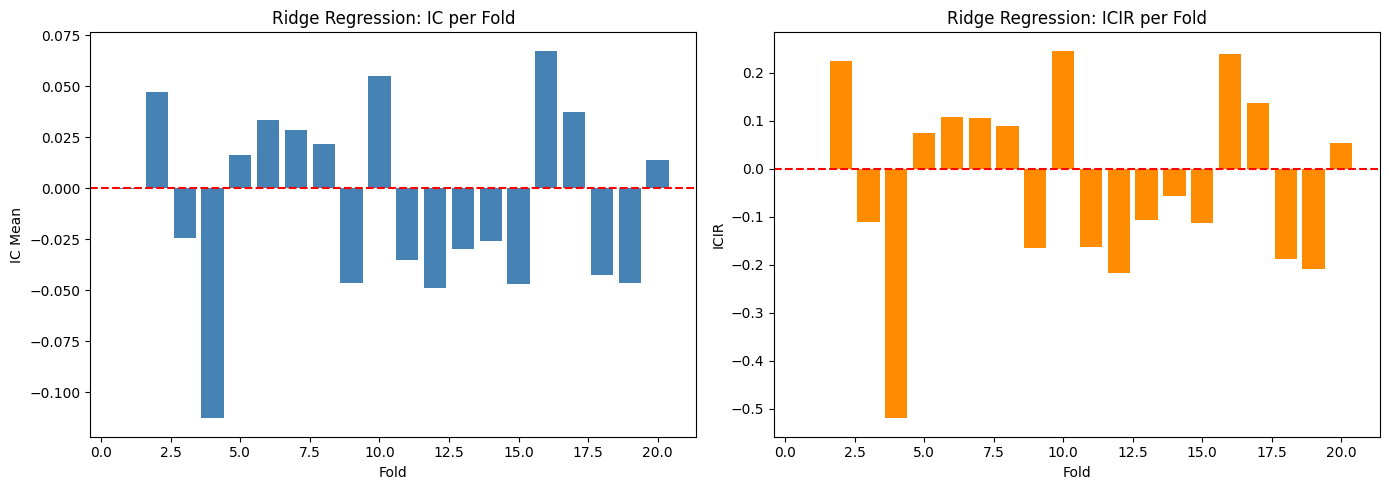

In [68]:
# Ridge Regression 汇总评估
reg_df = pd.DataFrame(reg_results)
print(f"\n平均指标:")
print(f"  MSE:  {reg_df['MSE'].mean():.6f}")
print(f"  MAE:  {reg_df['MAE'].mean():.4f}")
print(f"  R2:   {reg_df['R2'].mean():.4f}")
print(f"  IC:   {reg_df['IC Mean'].mean():.4f}")
print(f"  ICIR: {reg_df['ICIR'].mean():.4f}")

# 可视化：每个fold的IC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(reg_df['Fold'], reg_df['IC Mean'], color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('IC Mean')
axes[0].set_title('Ridge Regression: IC per Fold')

axes[1].bar(reg_df['Fold'], reg_df['ICIR'], color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('ICIR')
axes[1].set_title('Ridge Regression: ICIR per Fold')

plt.tight_layout()
plt.savefig('../results/ridge_regression_ic.png', dpi=150)
plt.show()

In [69]:
# 训练 Logistic Regression（分类），同理
cls_results = []
cls_predictions = []

for i, (train_dates, test_dates) in enumerate(folds):
    train = df_clean[df_clean['Date'].isin(train_dates)]
    test  = df_clean[df_clean['Date'].isin(test_dates)]

    X_train = train[alpha_cols]
    y_train = train['Direction']
    X_test  = test[alpha_cols]
    y_test  = test['Direction']

    # Logistic Regression（L2正则化，C=1.0是正则化强度的倒数）
    model_cls = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs')
    model_cls.fit(X_train, y_train)

    y_pred_proba = model_cls.predict_proba(X_test)[:, 1]  # 预测"上涨"的概率
    y_pred_label = model_cls.predict(X_test)

    # 评估指标
    auc = roc_auc_score(y_test, y_pred_proba)
    logloss = log_loss(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred_label)

    # 用预测概率算Rank IC（概率越高越看好，和实际收益率的rank相关性）
    test_with_pred = test[['Date', 'Ticker', 'Return_next']].copy()
    test_with_pred['y_proba'] = y_pred_proba

    daily_ic = test_with_pred.groupby('Date').apply(
        lambda x: spearmanr(x['y_proba'], x['Return_next'])[0]
    )
    ic_mean = daily_ic.mean()
    ic_ir = daily_ic.mean() / daily_ic.std() if daily_ic.std() > 0 else 0

    cls_results.append({
        'Fold': i + 1,
        'AUC': auc, 'Log Loss': logloss, 'Accuracy': acc,
        'IC Mean': ic_mean, 'ICIR': ic_ir
    })
    cls_predictions.append(test_with_pred)

    print(f"Fold {i+1}: AUC={auc:.4f}, LogLoss={logloss:.4f}, "
          f"Acc={acc:.4f}, IC={ic_mean:.4f}, ICIR={ic_ir:.4f}")

Fold 1: AUC=0.4945, LogLoss=0.6897, Acc=0.5597, IC=0.0551, ICIR=0.2773
Fold 2: AUC=0.5270, LogLoss=0.6673, Acc=0.6169, IC=0.0611, ICIR=0.3042
Fold 3: AUC=0.5387, LogLoss=0.6761, Acc=0.5927, IC=-0.0089, ICIR=-0.0463
Fold 4: AUC=0.4454, LogLoss=0.6911, Acc=0.5725, IC=-0.1131, ICIR=-0.6110
Fold 5: AUC=0.5044, LogLoss=0.6872, Acc=0.5643, IC=0.0071, ICIR=0.0324
Fold 6: AUC=0.5307, LogLoss=0.6914, Acc=0.5360, IC=0.1022, ICIR=0.3448
Fold 7: AUC=0.4613, LogLoss=0.7099, Acc=0.5088, IC=-0.0133, ICIR=-0.0495
Fold 8: AUC=0.4636, LogLoss=0.7205, Acc=0.4774, IC=-0.0475, ICIR=-0.1947
Fold 9: AUC=0.5025, LogLoss=0.7178, Acc=0.4559, IC=-0.0006, ICIR=-0.0024
Fold 10: AUC=0.5232, LogLoss=0.6747, Acc=0.5960, IC=0.0345, ICIR=0.1503
Fold 11: AUC=0.5023, LogLoss=0.6953, Acc=0.5336, IC=0.0002, ICIR=0.0009
Fold 12: AUC=0.4742, LogLoss=0.6679, Acc=0.6322, IC=-0.0614, ICIR=-0.2868
Fold 13: AUC=0.4802, LogLoss=0.7135, Acc=0.4781, IC=0.0147, ICIR=0.0683
Fold 14: AUC=0.4535, LogLoss=0.7004, Acc=0.5319, IC=-0.0931, 


平均指标:
  AUC:      0.4979
  Log Loss: 0.6923
  Accuracy: 0.5463
  IC:       -0.0053
  ICIR:     -0.0243


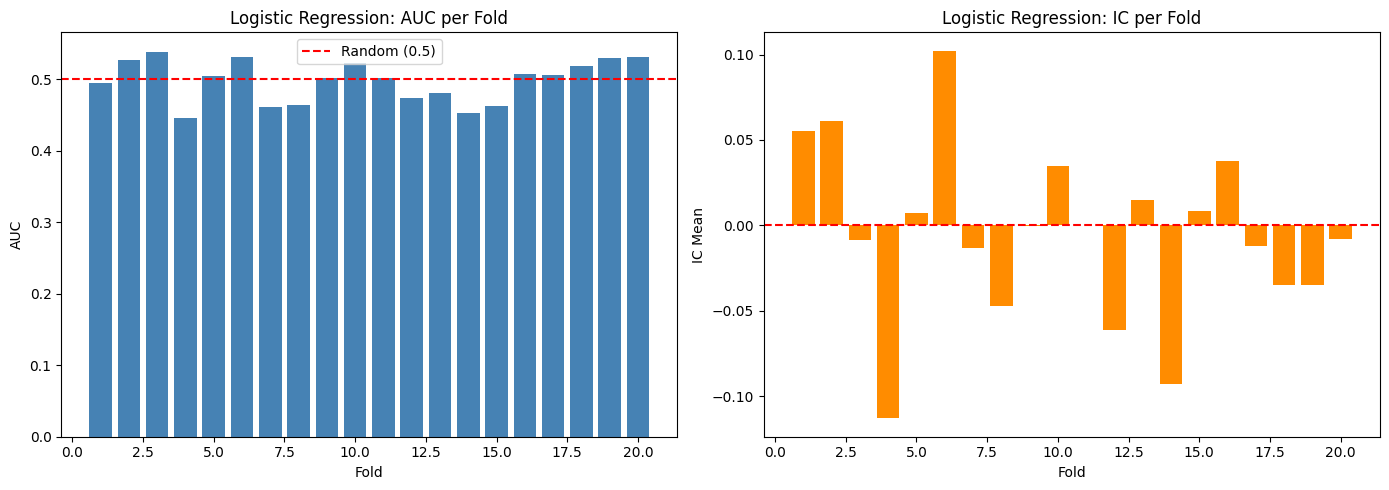

In [70]:
# Logistic Regression 汇总评估
cls_df = pd.DataFrame(cls_results)
print(f"\n平均指标:")
print(f"  AUC:      {cls_df['AUC'].mean():.4f}")
print(f"  Log Loss: {cls_df['Log Loss'].mean():.4f}")
print(f"  Accuracy: {cls_df['Accuracy'].mean():.4f}")
print(f"  IC:       {cls_df['IC Mean'].mean():.4f}")
print(f"  ICIR:     {cls_df['ICIR'].mean():.4f}")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(cls_df['Fold'], cls_df['AUC'], color='steelblue')
axes[0].axhline(0.5, color='red', linestyle='--', label='Random (0.5)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('AUC')
axes[0].set_title('Logistic Regression: AUC per Fold')
axes[0].legend()

axes[1].bar(cls_df['Fold'], cls_df['IC Mean'], color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('IC Mean')
axes[1].set_title('Logistic Regression: IC per Fold')

plt.tight_layout()
plt.savefig('../results/logistic_regression_ic.png', dpi=150)
plt.show()

In [71]:
# 两个模型对比
print(f"{'指标':<15} {'Ridge Regression':<20} {'Logistic Regression':<20}")
print("-" * 60)
print(f"{'IC Mean':<15} {reg_df['IC Mean'].mean():<20.4f} {cls_df['IC Mean'].mean():<20.4f}")
print(f"{'ICIR':<15} {reg_df['ICIR'].mean():<20.4f} {cls_df['ICIR'].mean():<20.4f}")
print(f"{'IC > 0 Folds':<15} {(reg_df['IC Mean'] > 0).sum()}/{len(reg_df):<17} "
      f"{(cls_df['IC Mean'] > 0).sum()}/{len(cls_df)}")

# Ridge 特有指标
print(f"\nRidge Regression:")
print(f"  平均 R2:  {reg_df['R2'].mean():.4f}")
print(f"  平均 MSE: {reg_df['MSE'].mean():.6f}")
print(f"  平均 MAE: {reg_df['MAE'].mean():.4f}")

# Logistic 特有指标
print(f"\nLogistic Regression:")
print(f"  平均 AUC:      {cls_df['AUC'].mean():.4f}")
print(f"  平均 Accuracy: {cls_df['Accuracy'].mean():.4f}")
print(f"  平均 Log Loss: {cls_df['Log Loss'].mean():.4f}")

指标              Ridge Regression     Logistic Regression 
------------------------------------------------------------
IC Mean         -0.0069              -0.0053             
ICIR            -0.0289              -0.0243             
IC > 0 Folds    9/20                9/20

Ridge Regression:
  平均 R2:  -0.0203
  平均 MSE: 0.002342
  平均 MAE: 0.0350

Logistic Regression:
  平均 AUC:      0.4979
  平均 Accuracy: 0.5463
  平均 Log Loss: 0.6923


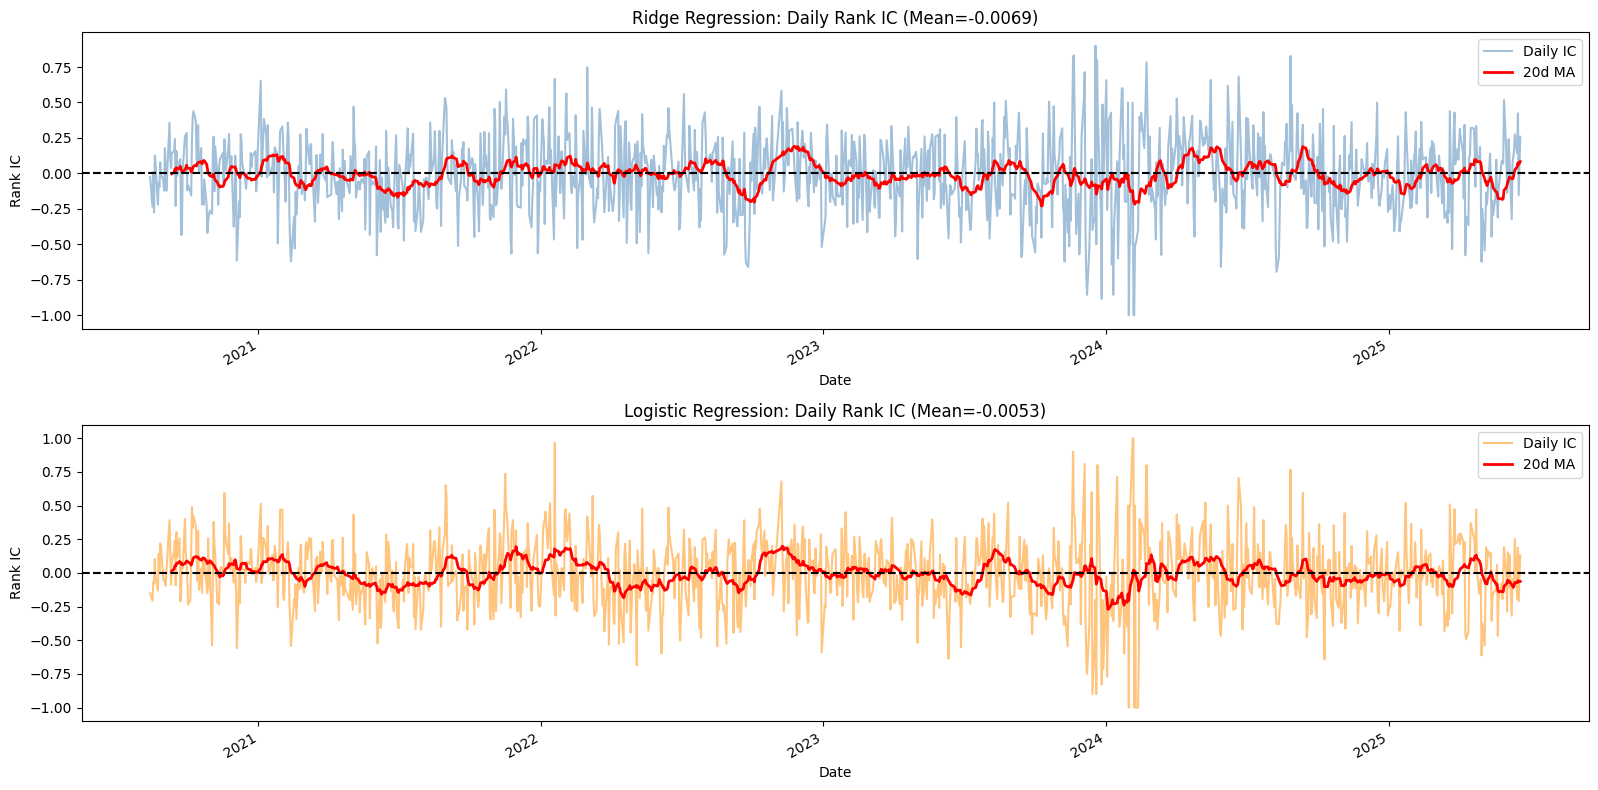

In [72]:
# IC时间序列图（合并所有fold的预测结果）
# Ridge的预测IC时间序列
all_reg_preds = pd.concat(reg_predictions)
reg_daily_ic = all_reg_preds.groupby('Date').apply(
    lambda x: spearmanr(x['y_pred'], x['y_true'])[0]
)

# Logistic的预测IC时间序列
all_cls_preds = pd.concat(cls_predictions)
cls_daily_ic = all_cls_preds.groupby('Date').apply(
    lambda x: spearmanr(x['y_proba'], x['Return_next'])[0]
)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

reg_daily_ic.plot(ax=axes[0], alpha=0.5, color='steelblue', label='Daily IC')
reg_daily_ic.rolling(20).mean().plot(ax=axes[0], color='red', linewidth=2, label='20d MA')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title(f'Ridge Regression: Daily Rank IC (Mean={reg_daily_ic.mean():.4f})')
axes[0].set_ylabel('Rank IC')
axes[0].legend()

cls_daily_ic.plot(ax=axes[1], alpha=0.5, color='darkorange', label='Daily IC')
cls_daily_ic.rolling(20).mean().plot(ax=axes[1], color='red', linewidth=2, label='20d MA')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title(f'Logistic Regression: Daily Rank IC (Mean={cls_daily_ic.mean():.4f})')
axes[1].set_ylabel('Rank IC')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/model_ic_timeseries.png', dpi=150)
plt.show()

# Part 4 - Portfolio Optimization

In [75]:
from scipy.optimize import minimize

portfolio_data_mvo = stocks_with_mvo[
    ['Date', 'Ticker', 'alpha_equal', 'Return']
].dropna().copy()
portfolio_data_mvo = portfolio_data_mvo.rename(columns={'alpha_equal': 'Score'})

# 宽表：日期 × 股票的日收益率（供MVO算协方差用）
return_pivot = stocks.pivot_table(index='Date', columns='Ticker', values='Return')

top_n        = 15      # 每次选Top 15只股票进MVO
lookback_cov = 120     # 用过去120天算协方差
risk_aversion = 2.0
rebalance_freq = 10

trade_dates      = sorted(portfolio_data_mvo['Date'].unique())
rebalance_dates  = trade_dates[::rebalance_freq]

# Benchmark：等权组合（只做多，不做空）
eq_daily = []
# 串联策略：MVO因子分选股 + MVO仓位优化
serial_daily = []

all_dates_list = sorted(return_pivot.index.tolist())

for rb_idx, rb_date in enumerate(rebalance_dates):
    day_data = portfolio_data_mvo[portfolio_data_mvo['Date'] == rb_date]
    if len(day_data) < 10:
        continue

    # 第一层结果：取综合分Top N只股票
    top_stocks = day_data.nlargest(top_n, 'Score')['Ticker'].tolist()

    # 等权benchmark权重
    eq_weights = pd.Series(1/len(top_stocks), index=top_stocks)

    # 第二层MVO：对Top N股票做仓位优化
    past_dates = [d for d in all_dates_list if d < rb_date][-lookback_cov:]
    cov_data   = return_pivot.loc[
        return_pivot.index.isin(past_dates), top_stocks
    ].dropna(axis=1)
    valid_stocks = cov_data.columns.tolist()

    if len(valid_stocks) < 5:
        mvo_weights = eq_weights.reindex(valid_stocks).fillna(1/len(valid_stocks))
    else:
        mu    = day_data[day_data['Ticker'].isin(valid_stocks)].set_index('Ticker')['Score']
        mu    = mu.reindex(valid_stocks).fillna(0).values
        Sigma = cov_data.cov().values + 0.001 * np.eye(len(valid_stocks))
        n     = len(valid_stocks)

        def neg_utility(w):
            return -(w @ mu - risk_aversion/2 * w @ Sigma @ w)

        res = minimize(neg_utility,
                       np.ones(n)/n,
                       method='SLSQP',
                       bounds=[(0, 0.20)]*n,
                       constraints={'type':'eq','fun': lambda w: w.sum()-1},
                       options={'ftol':1e-9,'maxiter':500})

        w = res.x if res.success else np.ones(n)/n
        w = np.clip(w, 0, None); w /= w.sum()
        mvo_weights = pd.Series(w, index=valid_stocks)

    # 持仓期收益
    if rb_idx + 1 < len(rebalance_dates):
        next_rb    = rebalance_dates[rb_idx + 1]
        hold_dates = [d for d in trade_dates if rb_date < d <= next_rb]
    else:
        hold_dates = [d for d in trade_dates if d > rb_date]

    for hd in hold_dates:
        if hd not in return_pivot.index:
            continue
        day_rets = return_pivot.loc[hd]

        serial_ret = sum(mvo_weights.get(t, 0) * day_rets.get(t, 0)
                         for t in valid_stocks)
        eq_ret     = day_rets.reindex(top_stocks).mean()

        serial_daily.append({'Date': hd, 'Return': serial_ret})
        eq_daily.append(   {'Date': hd, 'Return': eq_ret})

serial_df = pd.DataFrame(serial_daily).groupby('Date').mean().reset_index()
eq_df     = pd.DataFrame(eq_daily).groupby('Date').mean().reset_index()
print(f"回测完成，共 {len(serial_df)} 个交易日")

回测完成，共 2093 个交易日


# Part 5 - Performance Evaluation

MVO Factor Score + MVO Weights (Serial) | 年化:+24.46%  Sharpe:0.714  MaxDD:-42.01%
Equal Weight Benchmark (Top 15) | 年化:+26.69%  Sharpe:0.863  MaxDD:-37.56%
Market Equal Weight            | 年化:+22.20%  Sharpe:0.750  MaxDD:-34.41%


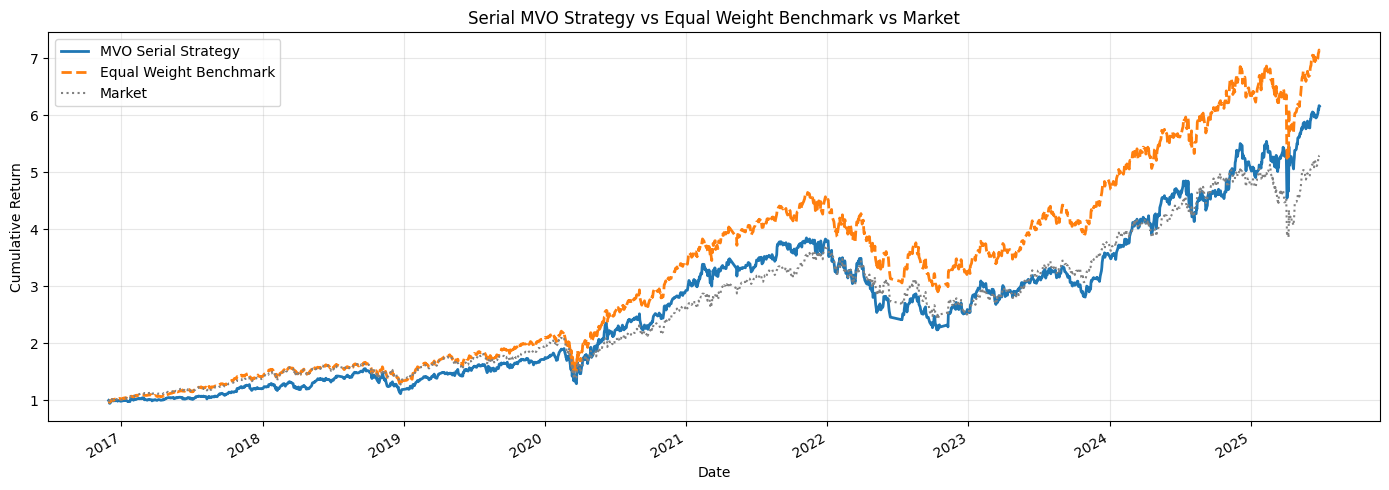

In [76]:
# 绩效对比
market_daily = stocks.groupby('Date')['Return'].mean().reset_index()
market_daily.columns = ['Date', 'Market_Return']

def calc_perf(ret_col, name):
    r = ret_col.dropna()
    total  = (1 + r).prod() - 1
    ann    = (1 + total) ** (252/len(r)) - 1
    sharpe = (ann - 0.04) / (r.std() * np.sqrt(252))
    cum    = (1 + r).cumprod()
    mdd    = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f"{name:30s} | 年化:{ann:+.2%}  Sharpe:{sharpe:.3f}  MaxDD:{mdd:.2%}")

print("="*75)
calc_perf(serial_df['Return'], "MVO Factor Score + MVO Weights (Serial)")
calc_perf(eq_df['Return'],     "Equal Weight Benchmark (Top 15)")
mkt = market_daily[market_daily['Date'].isin(serial_df['Date'])]['Market_Return']
calc_perf(mkt.reset_index(drop=True), "Market Equal Weight")
print("="*75)

# 累计收益曲线
fig, ax = plt.subplots(figsize=(14, 5))
(1 + serial_df.set_index('Date')['Return']).cumprod().plot(
    ax=ax, label='MVO Serial Strategy', linewidth=2)
(1 + eq_df.set_index('Date')['Return']).cumprod().plot(
    ax=ax, label='Equal Weight Benchmark', linewidth=2, linestyle='--')
mkt2 = market_daily[market_daily['Date'].isin(serial_df['Date'])].set_index('Date')
(1 + mkt2['Market_Return']).cumprod().plot(
    ax=ax, label='Market', linewidth=1.5, linestyle=':', color='gray')
ax.set_title('Serial MVO Strategy vs Equal Weight Benchmark vs Market')
ax.set_ylabel('Cumulative Return')
ax.legend(); 
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/serial_mvo_vs_benchmark.png', dpi=150)
plt.show()